# Phase 2: RFM Customer Segmentation

RFM (Recency, Frequency, Monetary) analysis is a proven marketing model for behavior-based customer segmentation. It groups customers based on their transaction history:
- **Recency**: How recently a customer has made a purchase
- **Frequency**: How often they purchase
- **Monetary**: How much they spend

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Processed Data

In [2]:
df = pd.read_csv('../data/processed/merged_olist_data.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
print(f"Loaded {df.shape[0]:,} rows.")

Loaded 113,425 rows.


## 2. Calculate RFM Metrics

In [3]:
now = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
df['total_value'] = df['price'].fillna(0) + df['freight_value'].fillna(0)

rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (now - x.max()).days, # Recency
    'order_id': 'nunique',                                      # Frequency
    'total_value': 'sum'                                        # Monetary
}).reset_index()

rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


## 3. RFM Scoring

In [4]:
r_labels = range(4, 0, -1)
r_quartiles = pd.qcut(rfm['Recency'], q=4, labels=r_labels)
rfm['R'] = r_quartiles.astype(str)

f_bins = [0, 1, 2, 3, np.inf]
f_labels = ['1', '2', '3', '4']
rfm['F'] = pd.cut(rfm['Frequency'], bins=f_bins, labels=f_labels).astype(str)

m_labels = range(1, 5)
m_quartiles = pd.qcut(rfm['Monetary'].rank(method='first'), q=4, labels=m_labels)
rfm['M'] = m_quartiles.astype(str)

rfm['RFM_Segment'] = rfm['R'] + rfm['F'] + rfm['M']
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R,F,M,RFM_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,3,413
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,214


## 4. Customer Segmentation

In [5]:
def segment_customer(row):
    r = int(row['R'])
    f = int(row['F'])
    if r >= 4 and f >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal'
    elif r <= 2 and f >= 2:
        return 'At-Risk'
    elif r <= 2 and f == 1:
        return 'Lost'
    else:
        return 'New/Recent'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']
segment_counts['Percentage'] = (segment_counts['Count'] / segment_counts['Count'].sum()) * 100
segment_counts

,Segment,Count,Percentage
0,Lost,46678,48.574342
1,New/Recent,46421,48.306901
2,Loyal,1566,1.629620
3,At-Risk,1343,1.397561
4,Champions,88,0.091575


## 5. Visualizing Segments

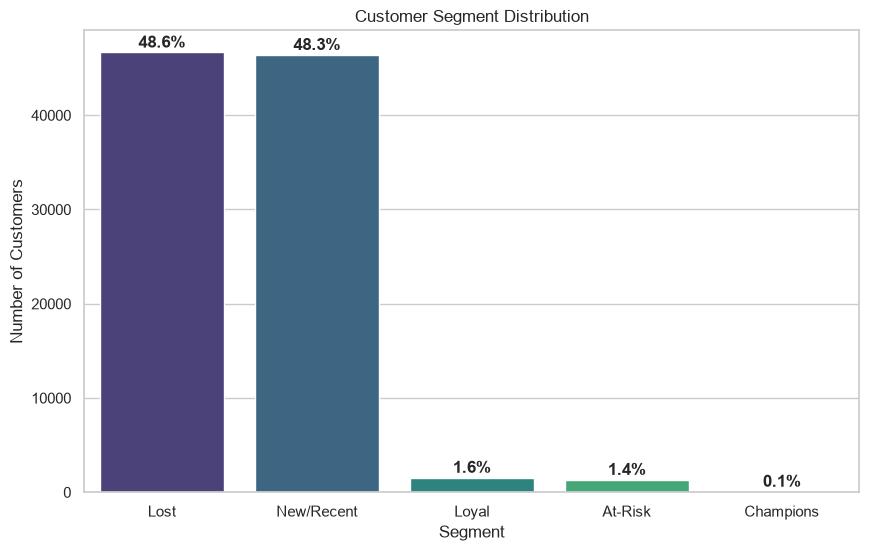

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='Count', data=segment_counts, hue='Segment', palette='viridis', legend=False)
plt.title('Customer Segment Distribution')
plt.ylabel('Number of Customers')
plt.xlabel('Segment')
for i, v in enumerate(segment_counts['Percentage']):
    plt.text(i, segment_counts['Count'].iloc[i] + 500, f'{v:.1f}%', ha='center', fontweight='bold')
plt.show()

## 6. Save RFM Data

In [7]:
df = df.merge(rfm[['customer_unique_id', 'Segment']], on='customer_unique_id', how='left')
df.to_csv('../data/processed/merged_olist_data.csv', index=False)
print("RFM Segments merged and dataset updated.")

RFM Segments merged and dataset updated.
